# Magseed CNN – ResUNet v6
**AI in Healthcare – SAT5114 | Group 4**

### Setup
1. Runtime → Change runtime type → **A100 GPU**
2. Runtime → **Run all**

## 1. Check GPU

In [1]:
#check gpu
import torch

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


## 2. Install & Download Dataset

In [2]:
#install dependencies
!pip install -q albumentations kagglehub

In [3]:
#download dataset
import kagglehub, shutil, os

path = kagglehub.dataset_download('awsaf49/cbis-ddsm-breast-cancer-image-dataset')
print(f'Dataset path: {path}')

DATA_ROOT = './data'
if not os.path.exists(DATA_ROOT):
    shutil.copytree(path, DATA_ROOT)
    print(f'Copied to {DATA_ROOT}')
else:
    print(f'{DATA_ROOT} already exists')
print('Contents:', os.listdir(DATA_ROOT))

100%|██████████| 4.95G/4.95G [00:27<00:00, 197MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1
Copied to ./data
Contents: ['csv', 'jpeg']


## 3. Dataset Loader

In [4]:
#imports
import os, glob
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

#config
IMAGE_SIZE = 384
BATCH_SIZE = 24

#train augmentation - flip, rotate, noise, elastic, grid distortion
def get_train_transforms(image_size=384):
    return A.Compose([
        A.Resize(image_size, image_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.Rotate(limit=20, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
        A.GaussNoise(p=0.2),
        A.ElasticTransform(alpha=60, sigma=60*0.05, p=0.2),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
        A.Normalize(mean=[0.485], std=[0.229]),
        ToTensorV2(),
    ], is_check_shapes=False)

#val augmentation - resize and normalize only
def get_val_transforms(image_size=384):
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=[0.485], std=[0.229]),
        ToTensorV2(),
    ], is_check_shapes=False)

#dataset class - loads cropped mammogram and roi mask pairs
class CBISDDSMDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        #load image as grayscale
        image = np.array(Image.open(self.image_paths[idx]).convert('L'), dtype=np.uint8)
        #load mask and resize to match image
        mask  = Image.open(self.mask_paths[idx]).convert('L')
        mask  = mask.resize((image.shape[1], image.shape[0]), Image.NEAREST)
        mask  = (np.array(mask, dtype=np.uint8) > 127).astype(np.float32)
        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask']
        if isinstance(image, torch.Tensor) and image.ndim == 2:
            image = image.unsqueeze(0)
        mask = (mask.unsqueeze(0) if isinstance(mask, torch.Tensor)
                else torch.tensor(mask).unsqueeze(0)).float()
        return image, mask

#resolve csv path to jpeg file
def resolve_jpeg(csv_path_str, jpeg_root):
    parts = csv_path_str.replace('\\', '/').split('/')
    if len(parts) < 3: return None
    folder = os.path.join(jpeg_root, parts[2])
    if not os.path.isdir(folder): return None
    jpgs = glob.glob(os.path.join(folder, '*.jpg'))
    return jpgs[0] if jpgs else None

#collect aligned cropped image and roi mask pairs from csv
def collect_aligned_pairs(data_root, split='train'):
    jpeg_root = os.path.join(data_root, 'jpeg')
    csv_root  = os.path.join(data_root, 'csv')
    tag       = 'train' if split == 'train' else 'test'
    imgs, masks = [], []
    skipped = 0
    for prefix in ['mass', 'calc']:
        csv_file = os.path.join(csv_root, f'{prefix}_case_description_{tag}_set.csv')
        if not os.path.exists(csv_file): continue
        df = pd.read_csv(csv_file)
        for _, row in df.iterrows():
            ip = resolve_jpeg(str(row['cropped image file path']), jpeg_root)
            mp = resolve_jpeg(str(row['ROI mask file path']),      jpeg_root)
            if ip and mp:
                try:
                    iw, ih = Image.open(ip).size
                    mw, mh = Image.open(mp).size
                    #verify image and mask dimensions match within 5 pixels
                    if abs(iw-mw) <= 5 and abs(ih-mh) <= 5:
                        imgs.append(ip); masks.append(mp)
                    else: skipped += 1
                except: skipped += 1
            else: skipped += 1
    print(f'  [{split}] {len(imgs)} aligned pairs | {skipped} skipped')
    return imgs, masks

#build train and val datasets
train_imgs, train_masks = collect_aligned_pairs(DATA_ROOT, 'train')
val_imgs,   val_masks   = collect_aligned_pairs(DATA_ROOT, 'test')

train_ds = CBISDDSMDataset(train_imgs, train_masks, get_train_transforms(IMAGE_SIZE))
val_ds   = CBISDDSMDataset(val_imgs,   val_masks,   get_val_transforms(IMAGE_SIZE))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch: {BATCH_SIZE}')

  [train] 2770 aligned pairs | 94 skipped
  [test] 693 aligned pairs | 11 skipped
Train: 2770 | Val: 693 | Image size: 384x384 | Batch: 24


## 4. ResUNet with Attention Gates

In [5]:
#imports
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

#conv block - 3x3 conv followed by batch norm and relu
class ConvBnRelu(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

#attention gate - filters skip connection using decoder gating signal
#suppresses irrelevant background tissue, amplifies lesion regions
class AttentionGate(nn.Module):
    def __init__(self, f_g, f_x, f_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(f_g, f_int, 1, bias=True), nn.BatchNorm2d(f_int))
        self.W_x = nn.Sequential(nn.Conv2d(f_x, f_int, 1, bias=True), nn.BatchNorm2d(f_int))
        self.psi = nn.Sequential(nn.Conv2d(f_int, 1, 1, bias=True), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        g1  = self.W_g(g)
        x1  = self.W_x(x)
        #upsample gating signal to match skip connection spatial size
        g1  = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

#decoder block - upsample + attention gate + two conv blocks + dropout
class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.2):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch//2, 2, stride=2)
        self.attn = AttentionGate(f_g=in_ch//2, f_x=skip_ch, f_int=skip_ch//2)
        self.conv = nn.Sequential(
            ConvBnRelu(in_ch//2 + skip_ch, out_ch),
            nn.Dropout2d(p=dropout),
            ConvBnRelu(out_ch, out_ch),
        )
    def forward(self, x, skip):
        x    = self.up(x)
        #pad if spatial dimensions differ
        dh   = skip.size(2) - x.size(2)
        dw   = skip.size(3) - x.size(3)
        x    = F.pad(x, [dw//2, dw-dw//2, dh//2, dh-dh//2])
        skip = self.attn(g=x, x=skip)
        return self.conv(torch.cat([x, skip], dim=1))

#resunet with attention gates
#encoder: pretrained resnet34 | decoder: 4 upsampling blocks with attention
class ResUNetAttention(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, pretrained=True, dropout=0.2):
        super().__init__()
        weights  = models.ResNet34_Weights.DEFAULT if pretrained else None
        resnet   = models.resnet34(weights=weights)
        #adapt first conv layer for grayscale by averaging rgb weights
        if in_channels == 1:
            orig = resnet.conv1
            new  = nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False)
            new.weight = nn.Parameter(orig.weight.mean(dim=1, keepdim=True))
            resnet.conv1 = new
        #encoder stages
        self.enc0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.pool = resnet.maxpool
        self.enc1 = resnet.layer1
        self.enc2 = resnet.layer2
        self.enc3 = resnet.layer3
        self.enc4 = resnet.layer4
        #decoder stages with attention gates on skip connections
        self.dec4 = DecoderBlock(512, 256, 256, dropout)
        self.dec3 = DecoderBlock(256, 128, 128, dropout)
        self.dec2 = DecoderBlock(128, 64,  64,  dropout)
        self.dec1 = DecoderBlock(64,  64,  32,  dropout)
        #output head
        self.final_up   = nn.ConvTranspose2d(32, 32, 2, stride=2)
        self.final_conv = nn.Sequential(ConvBnRelu(32, 16), nn.Conv2d(16, out_channels, 1))

    def forward(self, x):
        #encoder path
        e0 = self.enc0(x)
        e1 = self.enc1(self.pool(e0))
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        #decoder path with skip connections
        d  = self.dec4(e4, e3)
        d  = self.dec3(d,  e2)
        d  = self.dec2(d,  e1)
        d  = self.dec1(d,  e0)
        return self.final_conv(self.final_up(d))

#init model
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = ResUNetAttention(in_channels=1, out_channels=1, pretrained=True, dropout=0.2).to(DEVICE)
total  = sum(p.numel() for p in model.parameters()) / 1e6
print(f'ResUNet+Attention parameters: {total:.2f} M')
print(f'Device: {DEVICE}')

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 189MB/s]


ResUNet+Attention parameters: 24.44 M
Device: cuda


## 5. Loss & Metrics

In [6]:
#loss functions and metrics
EPS = 1e-6

#dice loss - measures overlap between predicted and true lesion mask
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__(); self.smooth = smooth
    def forward(self, logits, targets):
        p = torch.sigmoid(logits).view(-1); t = targets.view(-1)
        inter = (p*t).sum()
        return 1.0 - (2.0*inter + self.smooth) / (p.sum() + t.sum() + self.smooth)

#combined bce + dice loss
#pos_weight=2.0 gives lesion pixels double weight to push recall higher
class BCEDiceLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super().__init__()
        self.alpha = alpha
        self.bce   = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0]))
        self.dice  = DiceLoss()
    def forward(self, logits, targets):
        return self.alpha*self.bce(logits.cpu(), targets.cpu()) + (1-self.alpha)*self.dice(logits, targets)

#compute precision, recall, f1, iou for a batch
def compute_metrics(logits, targets, threshold=0.5):
    p  = (torch.sigmoid(logits) > threshold).float().view(-1)
    t  = targets.view(-1)
    TP = (p*t).sum().item(); FP = (p*(1-t)).sum().item(); FN = ((1-p)*t).sum().item()
    precision = TP/(TP+FP+EPS); recall = TP/(TP+FN+EPS)
    f1  = 2*precision*recall/(precision+recall+EPS)
    iou = TP/(TP+FP+FN+EPS)
    return dict(precision=precision, recall=recall, f1=f1, iou=iou)

#average a list of metric dicts into one epoch-level dict
def avg(ml):
    return {k: sum(m[k] for m in ml)/len(ml) for k in ml[0]}

print('Loss and metrics ready.')

Loss and metrics ready.


## 6. Train from Scratch

In [7]:
#imports
import time, json
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import autocast, GradScaler
from tqdm.notebook import tqdm

#hyperparameters
EPOCHS = 40
LR     = 1e-4
os.makedirs('./checkpoints', exist_ok=True)

best_iou = 0.0
print(f'Training from scratch for {EPOCHS} epochs')

#loss and optimizer
criterion = BCEDiceLoss(alpha=0.5)
scaler    = GradScaler()

#separate encoder and decoder params for differential learning rates
#encoder lr is 10x lower to preserve pretrained imagenet weights
encoder_params = (list(model.enc0.parameters()) + list(model.enc1.parameters()) +
                  list(model.enc2.parameters()) + list(model.enc3.parameters()) +
                  list(model.enc4.parameters()))
decoder_params = [p for p in model.parameters()
                  if not any(p is ep for ep in encoder_params)]

optimizer = optim.AdamW([
    {'params': encoder_params, 'lr': LR * 0.1},
    {'params': decoder_params, 'lr': LR},
], weight_decay=5e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

history  = {k: [] for k in ['train_loss','val_loss','val_iou','val_f1','val_precision','val_recall']}

#training loop
for epoch in range(EPOCHS):
    t0 = time.time()

    #train
    model.train()
    tl, tm = 0.0, []
    for imgs, masks in tqdm(train_loader, desc=f'Ep {epoch+1}/{EPOCHS} Train', leave=False):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        tl += loss.item()
        tm.append(compute_metrics(logits.detach().float(), masks.detach()))
    tl /= len(train_loader)

    #validate
    model.eval()
    vl, vm_list = 0.0, []
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f'Ep {epoch+1}/{EPOCHS} Val  ', leave=False):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            with autocast():
                logits = model(imgs)
            vl += criterion(logits.float(), masks).item()
            vm_list.append(compute_metrics(logits.float(), masks))
    vl /= len(val_loader)
    vm = avg(vm_list)
    scheduler.step()
    elapsed = time.time() - t0

    print(f'Epoch [{epoch+1}/{EPOCHS}]  '
          f'Loss train={tl:.4f} val={vl:.4f}  '
          f'IoU={vm["iou"]:.4f}  F1={vm["f1"]:.4f}  '
          f'Prec={vm["precision"]:.4f}  Rec={vm["recall"]:.4f}  ({elapsed:.0f}s)')

    #save history
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['val_iou'].append(vm['iou']); history['val_f1'].append(vm['f1'])
    history['val_precision'].append(vm['precision']); history['val_recall'].append(vm['recall'])

    #save best checkpoint by iou
    if vm['iou'] > best_iou:
        best_iou = vm['iou']
        torch.save({'epoch': epoch+1, 'model_state': model.state_dict(),
                    'best_iou': best_iou, 'arch': 'ResUNet-Attention-v6'},
                   './checkpoints/best_model.pth')
        print(f'  ✓ New best IoU={best_iou:.4f} saved!')
    print()

#save training history
with open('./checkpoints/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f'Training complete! Best IoU: {best_iou:.4f}')

Training from scratch for 40 epochs


/tmp/ipykernel_12380/2823491316.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()


Ep 1/40 Train:   0%|          | 0/116 [00:00<?, ?it/s]

/tmp/ipykernel_12380/2823491316.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep 1/40 Val  :   0%|          | 0/29 [00:00<?, ?it/s]

...

Ep 39/40 Val  :   0%|          | 0/29 [00:00<?, ?it/s]

Epoch [39/40]  Loss train=0.3747 val=0.3594  IoU=0.9196  F1=0.9578  Prec=0.9453  Rec=0.9711  (91s)
  ✓ New best IoU=0.9196 saved!



Ep 40/40 Train:   0%|          | 0/116 [00:00<?, ?it/s]

Ep 40/40 Val  :   0%|          | 0/29 [00:00<?, ?it/s]

Epoch [40/40]  Loss train=0.3799 val=0.3653  IoU=0.9061  F1=0.9504  Prec=0.9173  Rec=0.9865  (90s)

Training complete! Best IoU: 0.9196


## 7. Plot Training Curves

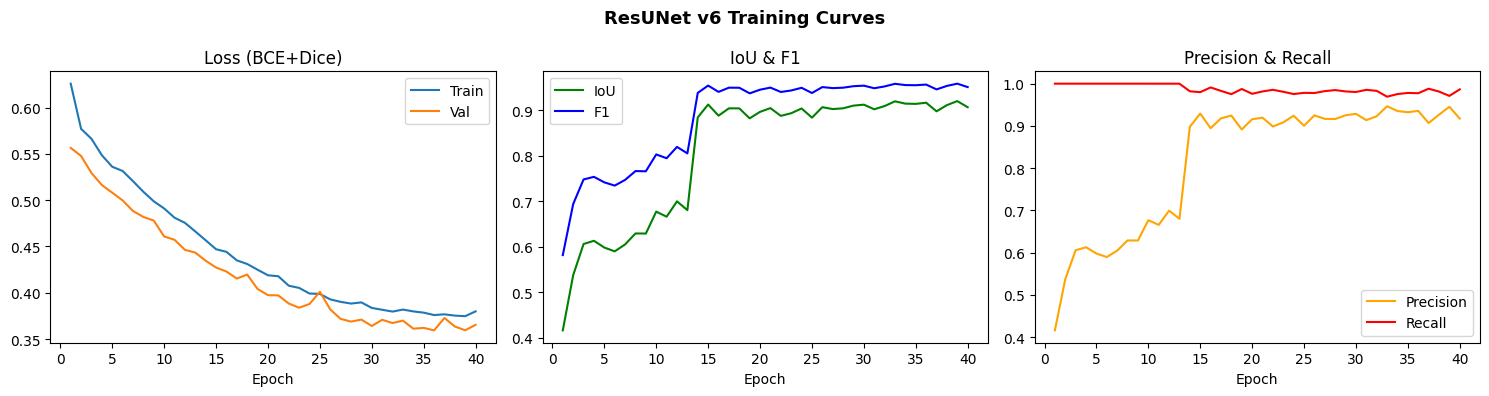

In [8]:
#plot training curves
import matplotlib.pyplot as plt

epochs = range(1, len(history['train_loss'])+1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('ResUNet v6 Training Curves', fontsize=13, fontweight='bold')

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss (BCE+Dice)'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs, history['val_iou'], color='green', label='IoU')
axes[1].plot(epochs, history['val_f1'],  color='blue',  label='F1')
axes[1].set_title('IoU & F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(epochs, history['val_precision'], color='orange', label='Precision')
axes[2].plot(epochs, history['val_recall'],    color='red',    label='Recall')
axes[2].set_title('Precision & Recall'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig('./checkpoints/training_curves.png', dpi=120)
plt.show()

## 8. Optimal Threshold Search
Finds the best prediction threshold between 0.30 and 0.55 on the full validation set.

Loaded best model — IoU=0.9196 from epoch 39



Predicting:   0%|          | 0/29 [00:00<?, ?it/s]

/tmp/ipykernel_12380/1514691793.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Searching optimal threshold...

Threshold search results:
  Best threshold : 0.56
  IoU at 0.50    : 0.9252
  IoU at 0.56   : 0.9274
  F1             : 0.9623
  Precision      : 0.9580
  Recall         : 0.9667


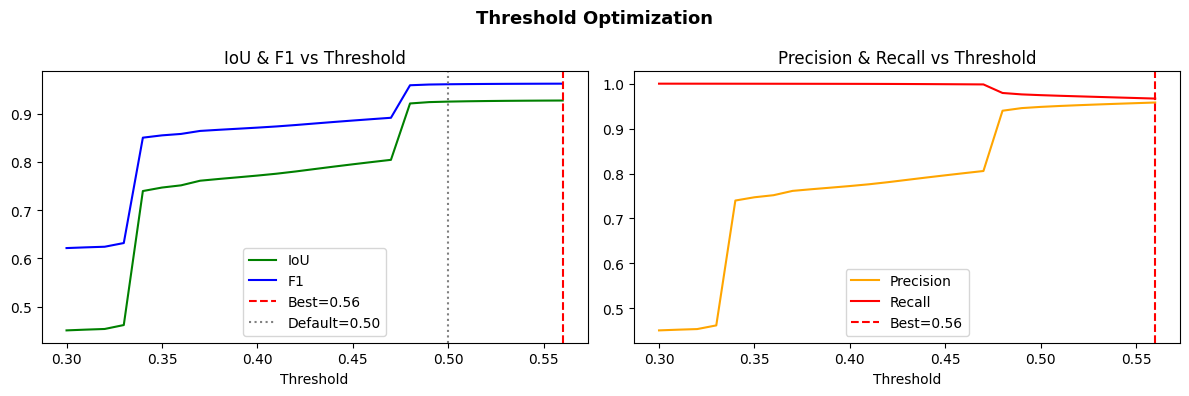

In [9]:
#load best model
ckpt = torch.load('./checkpoints/best_model.pth', map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Loaded best model — IoU={ckpt["best_iou"]:.4f} from epoch {ckpt["epoch"]}')

#collect all validation predictions
print('\nCollecting validation predictions...')
all_probs, all_masks_t = [], []
with torch.no_grad():
    for imgs, masks in tqdm(val_loader, desc='Predicting', leave=False):
        imgs = imgs.to(DEVICE)
        with autocast():
            logits = model(imgs)
        all_probs.append(torch.sigmoid(logits.float()).cpu())
        all_masks_t.append(masks)

all_probs   = torch.cat(all_probs,   dim=0)
all_masks_t = torch.cat(all_masks_t, dim=0)

#search thresholds 0.30 to 0.55
thresholds  = np.arange(0.30, 0.56, 0.01)
iou_scores, f1_scores, prec_scores, rec_scores = [], [], [], []

print('Searching optimal threshold...')
for thresh in thresholds:
    m = compute_metrics(torch.logit(all_probs.clamp(1e-6, 1-1e-6)), all_masks_t, threshold=thresh)
    iou_scores.append(m['iou']); f1_scores.append(m['f1'])
    prec_scores.append(m['precision']); rec_scores.append(m['recall'])

#find best threshold by iou
best_thresh_idx = int(np.argmax(iou_scores))
BEST_THRESHOLD  = float(thresholds[best_thresh_idx])

#print results
print(f'\nThreshold search results:')
print(f'  Best threshold : {BEST_THRESHOLD:.2f}')
print(f'  IoU at 0.50    : {iou_scores[int(np.argmin(np.abs(thresholds-0.50)))]:.4f}')
print(f'  IoU at {BEST_THRESHOLD:.2f}   : {iou_scores[best_thresh_idx]:.4f}')
print(f'  F1             : {f1_scores[best_thresh_idx]:.4f}')
print(f'  Precision      : {prec_scores[best_thresh_idx]:.4f}')
print(f'  Recall         : {rec_scores[best_thresh_idx]:.4f}')

#plot threshold vs metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Threshold Optimization', fontsize=13, fontweight='bold')
axes[0].plot(thresholds, iou_scores, color='green', label='IoU')
axes[0].plot(thresholds, f1_scores,  color='blue',  label='F1')
axes[0].axvline(BEST_THRESHOLD, color='red',  linestyle='--', label=f'Best={BEST_THRESHOLD:.2f}')
axes[0].axvline(0.50,           color='gray', linestyle=':',  label='Default=0.50')
axes[0].set_xlabel('Threshold'); axes[0].set_title('IoU & F1 vs Threshold'); axes[0].legend()
axes[1].plot(thresholds, prec_scores, color='orange', label='Precision')
axes[1].plot(thresholds, rec_scores,  color='red',    label='Recall')
axes[1].axvline(BEST_THRESHOLD, color='red', linestyle='--', label=f'Best={BEST_THRESHOLD:.2f}')
axes[1].set_xlabel('Threshold'); axes[1].set_title('Precision & Recall vs Threshold'); axes[1].legend()
plt.tight_layout()
plt.savefig('./checkpoints/threshold_search.png', dpi=120)
plt.show()

## 9. Inference with 8-way TTA + Optimal Threshold

Running 8-way TTA with optimal threshold=0.56



/tmp/ipykernel_12380/824731264.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


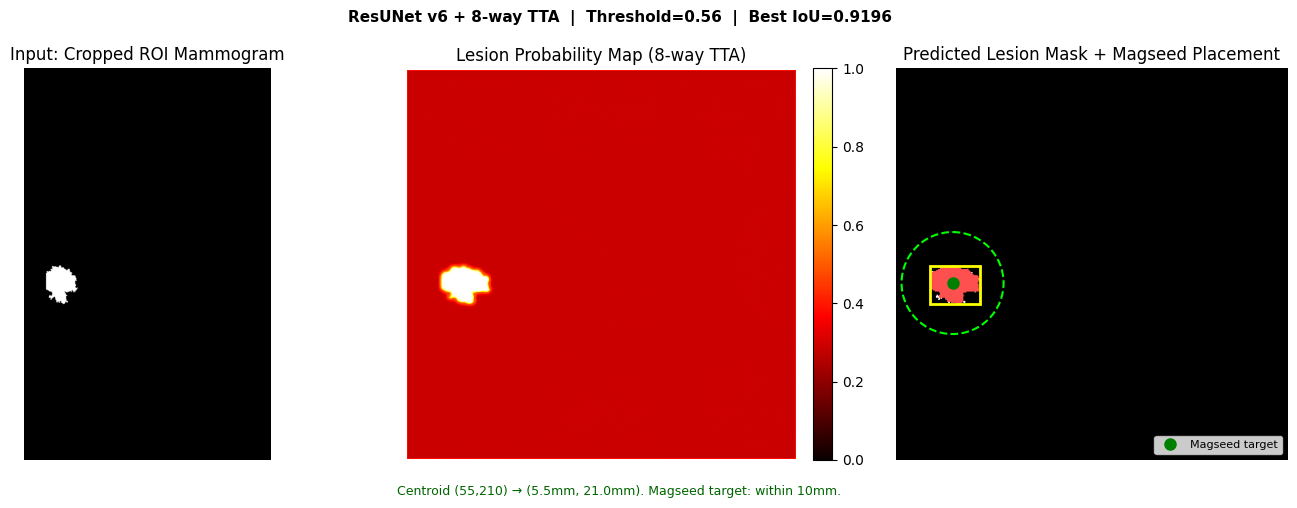

Centroid (55,210) → (5.5mm, 21.0mm). Magseed target: within 10mm.


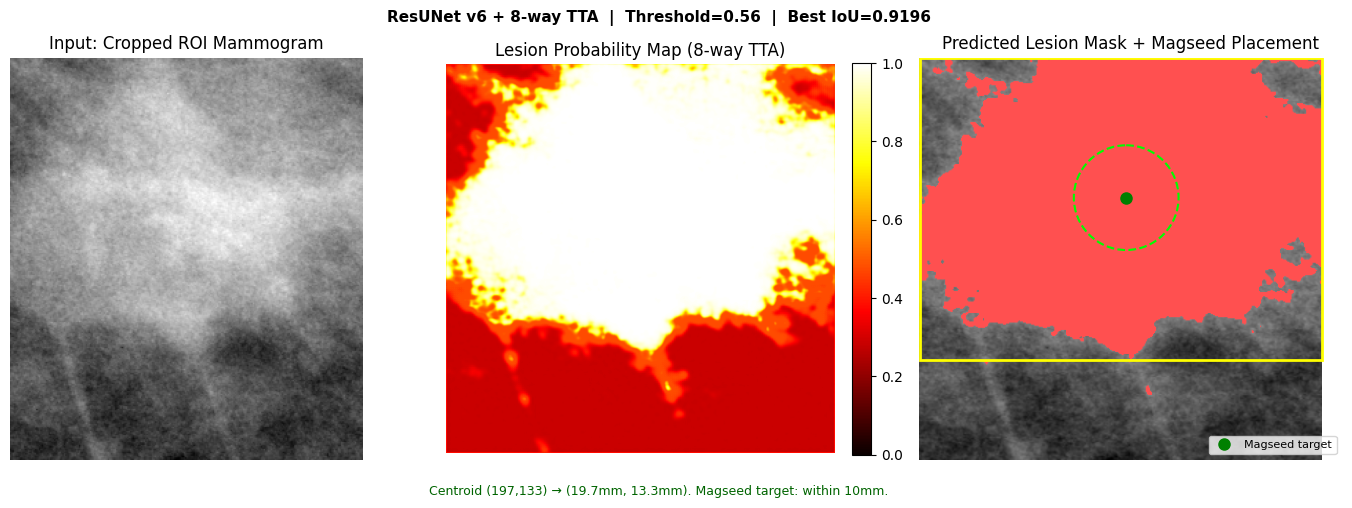

Centroid (197,133) → (19.7mm, 13.3mm). Magseed target: within 10mm.


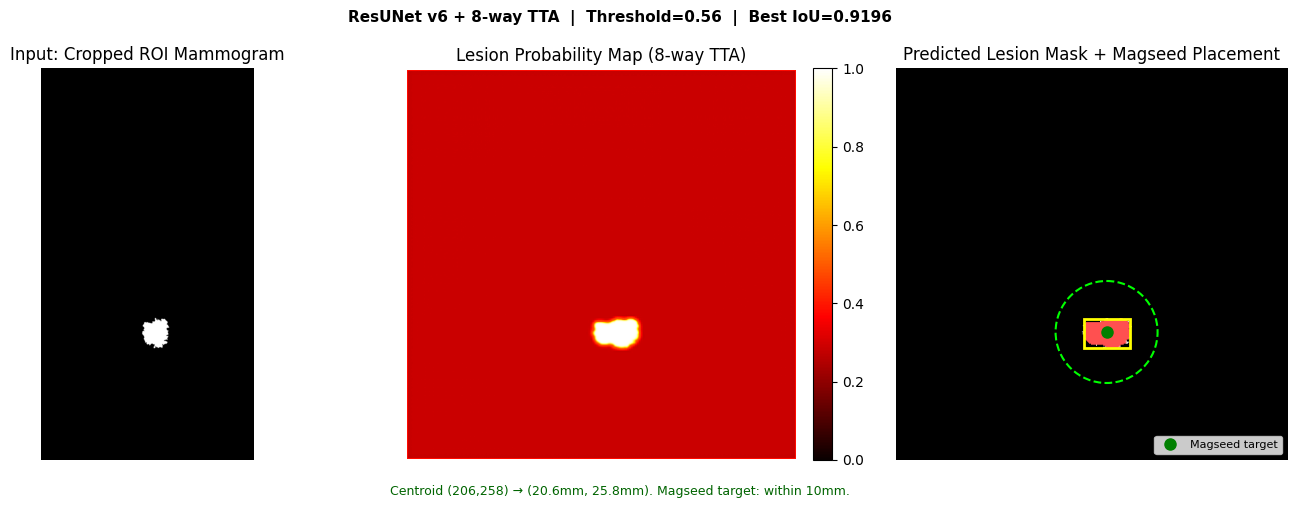

Centroid (206,258) → (20.6mm, 25.8mm). Magseed target: within 10mm.


In [10]:
#imports
import cv2
import matplotlib.patches as mpatches

#rotate image by 0, 90, 180, or 270 degrees
def rotate_image(img, angle):
    return np.rot90(img, k=angle//90)

#rotate prediction back to original orientation
def rotate_back(img, angle):
    return np.rot90(img, k=-(angle//90))

#8-way tta - predict on 4 rotations x 2 flips and average all 8 probability maps
def predict_8way_tta(model, image_np, transform, device, threshold=0.5):
    def get_prob(img_np):
        aug = transform(image=img_np.copy(), mask=np.zeros(img_np.shape[:2], dtype=np.uint8))
        t   = aug['image'].unsqueeze(0).to(device)
        with torch.no_grad():
            with autocast():
                return torch.sigmoid(model(t).float()).squeeze().cpu().numpy()

    prob_maps = []
    for angle in [0, 90, 180, 270]:
        rotated = rotate_image(image_np, angle)
        #original rotation prediction
        prob_maps.append(rotate_back(get_prob(rotated), angle))
        #horizontal flip prediction
        prob_maps.append(rotate_back(np.fliplr(get_prob(np.fliplr(rotated))), angle))

    #average all 8 predictions
    prob_map = np.mean(prob_maps, axis=0)
    bin_mask = (prob_map > threshold).astype(np.uint8)
    return prob_map, bin_mask

#run inference on 3 sample images
transform = get_val_transforms(IMAGE_SIZE)
print(f'Running 8-way TTA with optimal threshold={BEST_THRESHOLD:.2f}\n')

for sample_img_path in train_imgs[:3]:
    img_np   = np.array(Image.open(sample_img_path).convert('L'))
    prob_map, bin_mask = predict_8way_tta(model, img_np, transform, DEVICE, threshold=BEST_THRESHOLD)

    #find connected lesion regions
    num_labels, _, stats, centroids = cv2.connectedComponentsWithStats(bin_mask, connectivity=8)
    detected = num_labels > 1

    #plot results
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle(f'ResUNet v6 + 8-way TTA  |  Threshold={BEST_THRESHOLD:.2f}  |  Best IoU={ckpt["best_iou"]:.4f}',
                 fontsize=11, fontweight='bold')
    axes[0].imshow(img_np, cmap='gray')
    axes[0].set_title('Input: Cropped ROI Mammogram'); axes[0].axis('off')
    im = axes[1].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
    axes[1].set_title('Lesion Probability Map (8-way TTA)'); axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    h, w    = bin_mask.shape
    orig_rs = cv2.resize(img_np, (w,h))
    overlay = cv2.cvtColor(orig_rs, cv2.COLOR_GRAY2RGB)
    overlay[bin_mask==1] = [255, 80, 80]
    axes[2].imshow(overlay)
    axes[2].set_title('Predicted Lesion Mask + Magseed Placement'); axes[2].axis('off')

    if detected:
        #get largest connected component as primary lesion
        areas  = stats[1:, cv2.CC_STAT_AREA]; best = int(np.argmax(areas))+1
        cx, cy = int(centroids[best][0]), int(centroids[best][1])
        x,y,bw,bh = (stats[best,cv2.CC_STAT_LEFT], stats[best,cv2.CC_STAT_TOP],
                     stats[best,cv2.CC_STAT_WIDTH], stats[best,cv2.CC_STAT_HEIGHT])
        axes[2].add_patch(mpatches.Rectangle((x,y),bw,bh,lw=2,edgecolor='yellow',facecolor='none'))
        axes[2].plot(cx,cy,'go',markersize=8,label='Magseed target')
        axes[2].add_patch(plt.Circle((cx,cy),50,color='lime',fill=False,lw=1.5,linestyle='--'))
        axes[2].legend(loc='lower right',fontsize=8)
        note = f'Centroid ({cx},{cy}) → ({cx*0.1:.1f}mm, {cy*0.1:.1f}mm). Magseed target: within 10mm.'
    else:
        note = 'No lesion detected. Try a lower threshold.'

    fig.text(0.5, 0.01, note, ha='center', fontsize=9,
             color='darkgreen' if detected else 'red')
    plt.tight_layout(rect=[0,0.05,1,1])
    plt.show()
    print(note)

## 10. Full Model Version Comparison

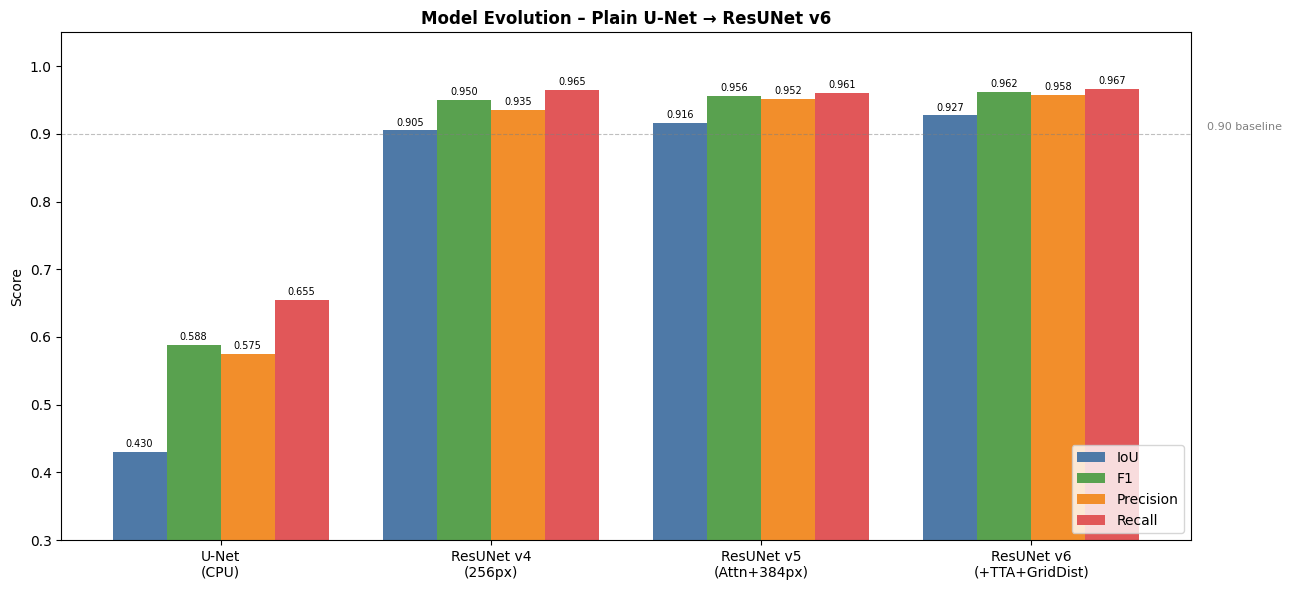


Full model comparison:
  U-Net (CPU)                          IoU=0.4300  F1=0.5879  Prec=0.5745  Rec=0.6550
  ResUNet v4 (256px)                   IoU=0.9052  F1=0.9500  Prec=0.9355  Rec=0.9653
  ResUNet v5 (Attn+384px)              IoU=0.9162  F1=0.9558  Prec=0.9517  Rec=0.9606
  ResUNet v6 (+TTA+GridDist)           IoU=0.9274  F1=0.9623  Prec=0.9580  Rec=0.9667


In [11]:
#model version comparison chart
import matplotlib.pyplot as plt
import numpy as np

#historical results across all versions
versions  = ['U-Net\n(CPU)', 'ResUNet v4\n(256px)', 'ResUNet v5\n(Attn+384px)', 'ResUNet v6\n(+TTA+GridDist)']
iou_vals  = [0.4300, 0.9052, 0.9162, iou_scores[best_thresh_idx]]
f1_vals   = [0.5879, 0.9500, 0.9558, f1_scores[best_thresh_idx]]
prec_vals = [0.5745, 0.9355, 0.9517, prec_scores[best_thresh_idx]]
rec_vals  = [0.6550, 0.9653, 0.9606, rec_scores[best_thresh_idx]]

x      = np.arange(len(versions))
width  = 0.2
colors = ['#4e79a7','#59a14f','#f28e2b','#e15759']

#plot grouped bar chart
fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x-1.5*width, iou_vals,  width, label='IoU',       color=colors[0])
bars2 = ax.bar(x-0.5*width, f1_vals,   width, label='F1',        color=colors[1])
bars3 = ax.bar(x+0.5*width, prec_vals, width, label='Precision', color=colors[2])
bars4 = ax.bar(x+1.5*width, rec_vals,  width, label='Recall',    color=colors[3])

for bars in [bars1, bars2, bars3, bars4]:
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=7)

ax.set_ylabel('Score')
ax.set_title('Model Evolution – Plain U-Net → ResUNet v6', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(versions)
ax.set_ylim(0.3, 1.05)
ax.legend(loc='lower right')
ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.text(3.65, 0.905, '0.90 baseline', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('./checkpoints/full_comparison.png', dpi=120)
plt.show()

#print comparison table
print('\nFull model comparison:')
for i, v in enumerate(versions):
    label = v.replace(chr(10), ' ')
    print(f'  {label:35s}  IoU={iou_vals[i]:.4f}  F1={f1_vals[i]:.4f}  Prec={prec_vals[i]:.4f}  Rec={rec_vals[i]:.4f}')